<a href="https://colab.research.google.com/github/sammanfatima/Python_Programming/blob/main/04_EDA_Analysis_on_Google_Play_Store_Apps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Playstore Data
## Complete EDA analysis for beginners to advance


# About Dataset
[ADVISORY] IMPORTANT
Instructions for citation:
If you use this dataset anywhere in your work, kindly cite as the below:
L. Gupta, "Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

Context
While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

Content
Each app (row) has values for catergory, rating, size, and more.

Acknowledgements
This information is scraped from the Google Play Store. This app information would not be available without it.

Inspiration
The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

# 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Machine Learning")

# 2. Data Loading and Exploration | Cleaning



*   Let's load the csv file




In [ ]:
df = pd.read_csv("googleplaystore.csv")



- Let's have a look on top 5 rows of the data



In [ ]:
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


- Important Things To Know

In [ ]:
# set option to be maximum for rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Hide all warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print(f"The name of columns in this dataset are as follows: {df.columns}")

The name of columns in this dataset are as follows: Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


In [ ]:
df.shape

(10841, 13)

In [ ]:
# [0] for rows
# [1] for columns
print(f"The numbers of rows are {df.shape[0]}, and Columns are {df.shape[1]}")

The numbers of rows are 10841, and Columns are 13


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# How to make a size numeric column?

* It returns all the value from that column

In [ ]:
df['Size'].value_counts()

,count
Size,
Varies with device,1695
11M,198
12M,196
14M,194
13M,191
15M,184
17M,160
19M,154
16M,149


In [ ]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

## Observations:
1. "Varries with device"
2. M
3. K

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df['Size'].isnull().sum()

np.int64(0)

- No missing values in size, we are good to go.

# Verify the numbers of values and 3 different kind of values

In [ ]:
df['Size'].loc[df['Size'].str.contains('M')].value_counts()

,count
Size,
11M,198
12M,196
14M,194
13M,191
15M,184
17M,160
19M,154
16M,149
26M,149


In [ ]:
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8829)

In [ ]:
# find values having k in them
df['Size'].loc[df['Size'].str.contains('k')].value_counts()

,count
Size,
375k,3
266k,3
201k,3
118k,3
79k,3
592k,2
58k,2
196k,2
51k,2


In [ ]:
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [ ]:
# find values having varies with device in them
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts()

,count
Size,
Varies with device,1695


In [ ]:
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum()

np.int64(1695)

In [ ]:
len(df)

10841

### Convert whole size column into bytes

* Let's define a function

In [ ]:
def convert_size(size):
  if isinstance(size, str):
    if 'K' in size:
      return float(size.replace('k', "")) * 1024
    elif 'M' in size:
      return float(size.replace('M', "")) * 1024 * 1024
    elif "Varies with device" in size:
      return np.nan
  return size

In [ ]:
df['Size']

,Size
0,19M
1,14M
2,8.7M
3,25M
4,2.8M
5,5.6M
6,19M
7,29M
8,33M
9,3.1M


In [ ]:
#lets apply the function
df['Size'] = df['Size'].apply(convert_size)

In [ ]:
df['Size']

,Size
0,19922944.0
1,14680064.0
2,9122611.2
3,26214400.0
4,2936012.8
5,5872025.6
6,19922944.0
7,30408704.0
8,34603008.0
9,3250585.6


In [ ]:
# rename the col
df.rename(columns={'Size': "Size_in_bytes"}, inplace=True)

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# Let's take care of installs

In [ ]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [ ]:
df['Installs'].value_counts()

,count
Installs,
"1,000,000+",1579
"10,000,000+",1252
"100,000+",1169
"10,000+",1054
"1,000+",907
"5,000,000+",752
100+,719
"500,000+",539
"50,000+",479


In [ ]:
df['Installs'].isnull().sum()

np.int64(0)

# Installs Column

1. Reemove + sign
2. remove ,
3. convert the col into integer

In [ ]:
df["Installs"] = df['Installs'].apply(lambda x: x.replace('+', "")if '+' in str(x) else x)

In [ ]:
df["Installs"] = df['Installs'].apply(lambda x: x.replace(',', "")if ',' in str(x) else x)

In [ ]:
df['Installs'].value_counts()

,count
Installs,
1000000,1579
10000000,1252
100000,1169
10000,1054
1000,907
5000000,752
100,719
500000,539
50000,479


In [ ]:
df.head()

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# Price column

In [ ]:
df['Price'].value_counts()

,count
Price,
0,10040
$0.99,148
$2.99,129
$1.99,73
$4.99,72
$3.99,63
$1.49,46
$5.99,30
$2.49,26


In [ ]:
df['Price'].str.contains(r'\$', na=False).sum()

np.int64(800)

In [ ]:
# dollar and without dollar
df['Price'].loc[df['Price'].str.contains('$')].value_counts().sum()

np.int64(10841)

In [ ]:
df['Price'].loc[df['Price'].str.contains('0')].value_counts().sum()

np.int64(10223)

In [ ]:
df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [ ]:
df['Price'] = df['Price'].apply(lambda x: x.replace('$', "") if '$' in str(x) else x)

In [ ]:
df['Price'].value_counts()

,count
Price,
0,10040
0.99,148
2.99,129
1.99,73
4.99,72
3.99,63
1.49,46
5.99,30
2.49,26


In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
# using f string print min, max, avg prices of app
print(f"Min Price is {df["Price"].min()}")
print(f"Max Price is {df["Price"].max()}")
print(f"Average Price is {df["Price"].mean()}")


Min Price is 0
Max Price is Everyone


TypeError: Could not convert string '0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000004.994.990000000000000000000000000000000000000000000000000000004.994.990000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000003.990000000000000000000000000000000000000000000000003.996.991.492.993.997.99000000000000000000000000000000000000000000000000000000000000000000000000000000000000000003.990000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000003.995.993.993.99000000000000000000000000000000000000000000000000000000000000

# Missing values inside the data

In [ ]:
#find missing values
df.isnull().sum().sort_values(ascending=False)

,0
Size_in_bytes,1695
Rating,1474
Current Ver,8
Android Ver,3
Type,1
Content Rating,1
Reviews,0
App,0
Category,0
Price,0


In [ ]:
#find total values of missing values
df.isnull().sum().sum()

np.int64(3182)

<Axes: >

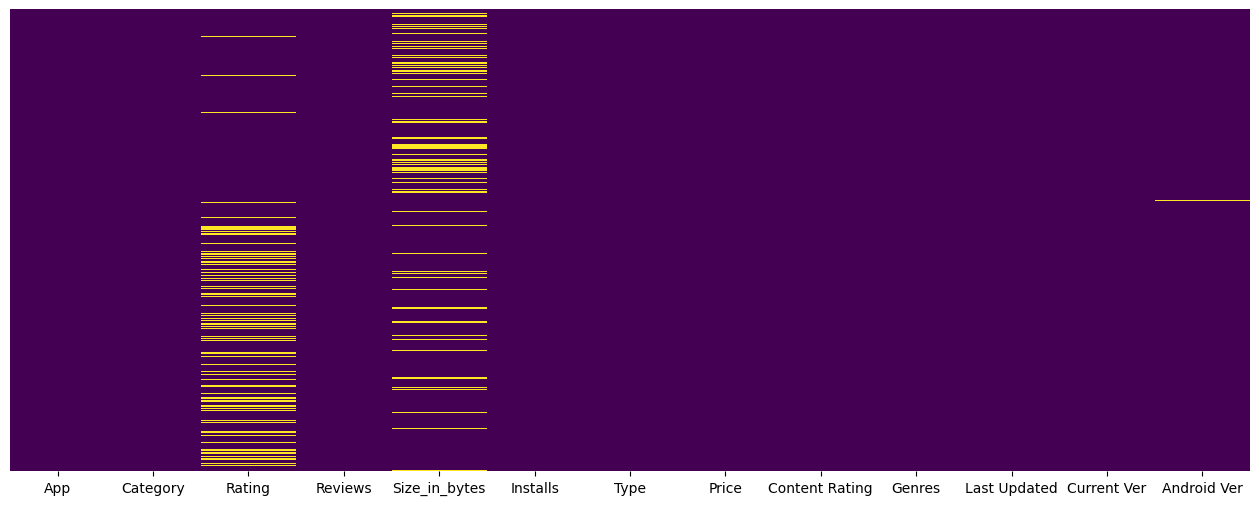

In [ ]:
#plot missing values
plt.figure(figsize=(16,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Text(0.5, 1.0, 'Percentage of Missing values in each column')

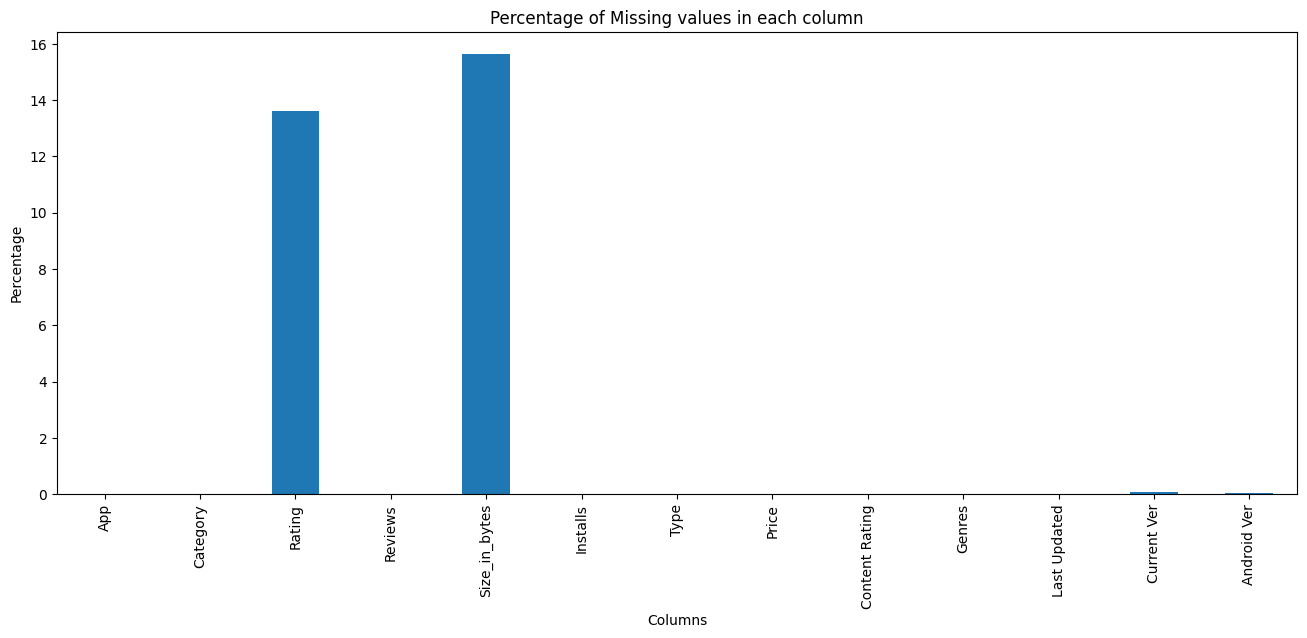

In [ ]:
plt.figure(figsize=(16,6))
#plot the null values by their percentagein each column
missing_percentage = df.isnull().sum()/ len(df)*100
missing_percentage.plot(kind='bar')
#add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing values in each column')

<Axes: >

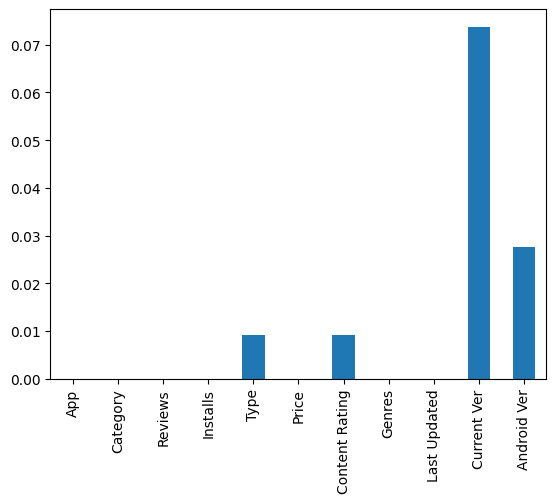

In [ ]:
missing_percentage[missing_percentage < 1].plot(kind='bar')

In [ ]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

,Installs
Category,
1.9,Free
LIBRARIES_AND_DEMO,5000010000100000100010000010000100000500000050...
BEAUTY,5000001000000100000500000100000050000010000010...
LIFESTYLE,5000000100000001000001000000050000001000000500...
WEATHER,5000000010000005000000010000100000001000000100...
PERSONALIZATION,5000000010000001000000005000000100000500000050...
FAMILY,5000000010000000100000000100000050000005000000...
PRODUCTIVITY,5000000001000000010000000010000000100000000010...
ART_AND_DESIGN,1000050000050000005000000010000050000500001000...


In [ ]:
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10)

,Reviews
Category,
PARENTING,8617941763614343114133936378967107559497632484...
SOCIAL,7815830666577313860625949173295532622492170147...
MAPS_AND_NAVIGATION,7232629156815348110480050459432695644349284201...
EDUCATION,6289924181893254485375314299776977032346407510...
COMMUNICATION,5664284769119316125257964299514290354604324341...
ENTERTAINMENT,5456208116562894829677147008910939985095241225...
SPORTS,5211381802283662828824597951338259119951733342...
FAMILY,4706944214544499101477412753339832026757611161...
GAME,4447388277222642242667725425814889736920352341...
